In [1]:
import os
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
# 加载 GPT2 模型
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# 加载模型
model_hf = GPT2LMHeadModel.from_pretrained("gpt2")
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

# 下载并加载 gpt2 模型
# model_hf = GPT2LMHeadModel.from_pretrained("gpt2")
sd_hf = model_hf.state_dict()  # 获取模型参数

# 打印所有参数名称 + 形状
print("=== GPT2 模型所有参数 ===")
for k, v in sd_hf.items():
    print(f"{k:<50} {v.shape}")

c:\Users\cys\anaconda3\envs\py310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\cys\anaconda3\envs\py310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\cys\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this art

=== GPT2 模型所有参数 ===
transformer.wte.weight                             torch.Size([50257, 768])
transformer.wpe.weight                             torch.Size([1024, 768])
transformer.h.0.ln_1.weight                        torch.Size([768])
transformer.h.0.ln_1.bias                          torch.Size([768])
transformer.h.0.attn.c_attn.weight                 torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias                   torch.Size([2304])
transformer.h.0.attn.c_proj.weight                 torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias                   torch.Size([768])
transformer.h.0.ln_2.weight                        torch.Size([768])
transformer.h.0.ln_2.bias                          torch.Size([768])
transformer.h.0.mlp.c_fc.weight                    torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias                      torch.Size([3072])
transformer.h.0.mlp.c_proj.weight                  torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias              

c:\Users\cys\anaconda3\envs\py310\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [3]:
sd_hf["transformer.wpe.weight"].view(-1)[:20]

tensor([-0.0188, -0.1974,  0.0040,  0.0113,  0.0638, -0.1050,  0.0369, -0.1680,
        -0.0491, -0.0565, -0.0025,  0.0135, -0.0042,  0.0151,  0.0166, -0.1381,
        -0.0063, -0.0461,  0.0267, -0.2042])

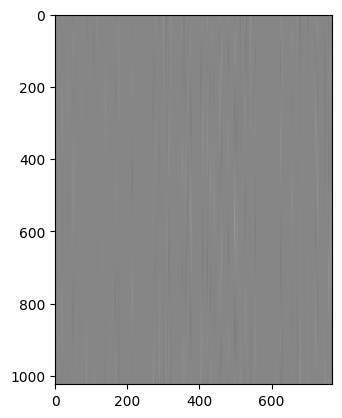

In [4]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(sd_hf["transformer.wpe.weight"],cmap="gray")

In [13]:
# plt.imshow(sd_hf["transformer.wpe.weight"][:,150])
# plt.imshow(sd_hf["transformer.wpe.weight"][:,200])
# plt.imshow(sd_hf["transformer.wpe.weight"][:,250])

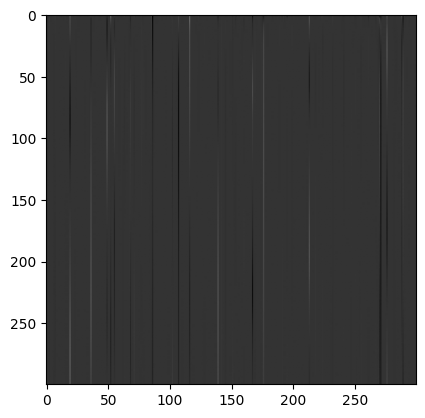

In [6]:
plt.imshow(sd_hf["transformer.wpe.weight"][:300,:300],cmap="gray")

In [8]:
from transformers import pipeline,set_seed
generator =  pipeline('text-generation',model='gpt2')
set_seed(42)
generator("Hello,I'm a  language model.",max_length = 30,num_return_sequences=3)


c:\Users\cys\anaconda3\envs\py310\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[{'generated_text': "Hello,I'm a  language model. It means that in the world where my languages are not represented, my languages are not expressed, and those"},
 {'generated_text': "Hello,I'm a  language model. \xa0I would love to come out and tell you about this wonderful \xa0kindle I'm about"},
 {'generated_text': "Hello,I'm a  language model.\n\nYou should get familiar with Python (Python 2) and Python 3, but I won't have"}]